<a href="https://colab.research.google.com/github/Zafar488/Portfolio/blob/main/MaternalGuard_3_Datasets_Industry_FIXED_V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MaaHifazat AI — MaternalGuard V3

## Corrected Industry-Level Multi-Source Training Workflow

This notebook uses three automatically downloadable public maternal-health datasets:

1. **UCI Maternal Health Risk — Bangladesh**
2. **Tanzania Maternal Health Risks Stratification (MHRS)**
3. **Maternal Health and High-Risk Pregnancy — Zenodo**

The previous workflow retained only 1,027 rows and accidentally trained primarily on 13 Tanzania records. This version fixes that problem by using **source-specific parsers** rather than unreliable generic alias matching.

## Major corrections

- Tanzania longitudinal visit columns are aggregated from the **first available ANC visit**.
- Tanzania `no_pregnancy` is mapped to gravida.
- Tanzania `duration_of_pregnancy_weeks_` is mapped to gestational age.
- Tanzania blood pressure strings are split into systolic and diastolic values.
- Bengali Zenodo columns are explicitly mapped.
- Bengali blood pressure, gestational age, weight, height, gravida and fetal heart rate are parsed.
- Height values such as `5.3''` are interpreted as 5 feet 3 inches.
- Source-specific row-count assertions prevent silent data loss.
- Features need coverage in at least two sources.
- All three sources are represented in the primary train/test split.
- Source/class-balanced sample weights prevent Tanzania from dominating training.
- Exact duplicate records are removed.
- Conflicting identical signatures are excluded.
- Group-safe cross-validation prevents duplicate leakage.
- Leave-one-source-out results are reported only as a domain-shift stress test.

## Harmonized prediction target

- `0 = not_high_risk`
- `1 = high_risk`

For UCI, `low risk` and `mid risk` are combined into `not_high_risk`.

> **Clinical notice:** This is a research and hackathon prototype. It is not clinically validated and cannot replace qualified healthcare professionals.

## Step 1 — Install dependencies

In [1]:
%%capture
!pip install -U \
    "pandas>=2.0,<4.0" \
    "numpy>=1.24,<3.0" \
    "scipy>=1.10" \
    "matplotlib>=3.7" \
    "scikit-learn>=1.4,<2.0" \
    "xgboost>=2.0,<4.0" \
    "ucimlrepo>=0.0.7" \
    "openpyxl>=3.1" \
    "pyarrow>=15.0" \
    "joblib>=1.3" \
    "requests>=2.31" \
    "fastapi>=0.110" \
    "uvicorn>=0.27" \
    "pydantic>=2.6"

## Step 2 — Imports and reproducibility

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import random
import re
import shutil
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import sklearn
import xgboost

from scipy.stats import randint, loguniform, uniform
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedGroupKFold,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

SEED = 42
FAST_MODE = True
SEARCH_ITERATIONS = 15 if FAST_MODE else 50
CV_SPLITS = 5
TARGET_HIGH_RISK_RECALL = 0.90
MODEL_VERSION = "3.1.0"

np.random.seed(SEED)
random.seed(SEED)

ROOT = Path("/content/maternalguard_v3")
RAW_DIR = ROOT / "raw"
PROCESSED_DIR = ROOT / "processed"
ARTIFACT_DIR = ROOT / "artifacts"

for directory in [RAW_DIR, PROCESSED_DIR, ARTIFACT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("Project root:", ROOT)

Python: 3.12.13
pandas: 3.0.3
scikit-learn: 1.9.0
XGBoost: 3.3.0
Project root: /content/maternalguard_v3


## Step 3 — Public dataset registry

In [2]:
DATASET_REGISTRY = {
    "uci_bangladesh": {
        "type": "uci",
        "id": 863,
        "license": "CC BY 4.0",
    },
    "tanzania_mhrs": {
        "type": "zenodo",
        "record_id": "15309733",
        "filename": "maternal_dataset_csv.csv",
        "license": "CC BY 4.0",
    },
    "zenodo_high_risk": {
        "type": "zenodo",
        "record_id": "14537882",
        "filename": "Book2.xlsx",
        "license": "CC BY 4.0",
    },
}

print(json.dumps(DATASET_REGISTRY, indent=2))

{
  "uci_bangladesh": {
    "type": "uci",
    "id": 863,
    "license": "CC BY 4.0"
  },
  "tanzania_mhrs": {
    "type": "zenodo",
    "record_id": "15309733",
    "filename": "maternal_dataset_csv.csv",
    "license": "CC BY 4.0"
  },
  "zenodo_high_risk": {
    "type": "zenodo",
    "record_id": "14537882",
    "filename": "Book2.xlsx",
    "license": "CC BY 4.0"
  }
}


## Step 4 — Download helpers

In [3]:
def stream_download(
    url: str,
    output_path: Path,
    expected_md5: str | None = None,
) -> Path:
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists() and output_path.stat().st_size > 0:
        print("Already downloaded:", output_path.name)
        return output_path

    with requests.get(url, stream=True, timeout=300) as response:
        response.raise_for_status()
        with output_path.open("wb") as file:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    file.write(chunk)

    if expected_md5:
        digest = hashlib.md5(output_path.read_bytes()).hexdigest()
        if digest.lower() != expected_md5.lower():
            output_path.unlink(missing_ok=True)
            raise ValueError(
                f"Checksum mismatch for {output_path.name}: {digest}"
            )

    print("Downloaded:", output_path.name)
    return output_path


def download_zenodo_file(
    record_id: str,
    filename: str,
) -> Path:
    metadata_url = f"https://zenodo.org/api/records/{record_id}"
    response = requests.get(metadata_url, timeout=90)
    response.raise_for_status()
    metadata = response.json()

    file_record = next(
        (
            item
            for item in metadata.get("files", [])
            if item.get("key") == filename
        ),
        None,
    )

    if file_record is None:
        available = [
            item.get("key")
            for item in metadata.get("files", [])
        ]
        raise FileNotFoundError(
            f"{filename} was not found. Available files: {available}"
        )

    url = (
        file_record.get("links", {}).get("content")
        or file_record.get("links", {}).get("self")
    )

    checksum = file_record.get("checksum", "")
    expected_md5 = (
        checksum.split(":", 1)[1]
        if checksum.startswith("md5:")
        else None
    )

    return stream_download(
        url=url,
        output_path=RAW_DIR / filename,
        expected_md5=expected_md5,
    )

## Step 5 — Download and load the datasets

In [4]:
from ucimlrepo import fetch_ucirepo


def load_uci() -> pd.DataFrame:
    dataset = fetch_ucirepo(id=863)
    features = dataset.data.features.reset_index(drop=True)
    targets = dataset.data.targets.reset_index(drop=True)

    if isinstance(targets, pd.Series):
        targets = targets.to_frame(name="RiskLevel")

    frame = pd.concat([features, targets], axis=1)
    frame = frame.dropna(how="all").reset_index(drop=True)
    frame.to_csv(RAW_DIR / "uci_maternal_health.csv", index=False)
    return frame


def load_best_excel_table(path: Path) -> pd.DataFrame:
    workbook = pd.ExcelFile(path)
    candidates = []

    target_column_name = "ঝুকিপূর্ণ গর্ভ"

    for sheet_name in workbook.sheet_names:
        for header_row in range(0, 11):
            try:
                frame = pd.read_excel(
                    path,
                    sheet_name=sheet_name,
                    header=header_row,
                )
                frame = frame.dropna(axis=0, how="all")
                frame = frame.dropna(axis=1, how="all")
                frame.columns = [
                    str(column).strip()
                    for column in frame.columns
                ]

                score = len(frame)
                if target_column_name in frame.columns:
                    score += 100_000
                if "Age" in frame.columns:
                    score += 10_000
                if "Gravida" in frame.columns:
                    score += 10_000

                candidates.append(
                    (score, sheet_name, header_row, frame)
                )
            except Exception:
                continue

    if not candidates:
        raise ValueError("No valid table found inside the Excel workbook.")

    candidates.sort(key=lambda item: item[0], reverse=True)
    score, sheet_name, header_row, frame = candidates[0]

    print(
        "Selected Excel table:",
        {
            "sheet": sheet_name,
            "header_row": header_row,
            "shape": frame.shape,
        },
    )
    print("Columns:", frame.columns.tolist())
    return frame.reset_index(drop=True)


uci_raw = load_uci()

tanzania_path = download_zenodo_file(
    record_id=DATASET_REGISTRY["tanzania_mhrs"]["record_id"],
    filename=DATASET_REGISTRY["tanzania_mhrs"]["filename"],
)
tanzania_raw = pd.read_csv(tanzania_path, low_memory=False)
tanzania_raw = tanzania_raw.dropna(how="all").reset_index(drop=True)

zenodo_path = download_zenodo_file(
    record_id=DATASET_REGISTRY["zenodo_high_risk"]["record_id"],
    filename=DATASET_REGISTRY["zenodo_high_risk"]["filename"],
)
zenodo_raw = load_best_excel_table(zenodo_path)

print("UCI raw shape:", uci_raw.shape)
print("Tanzania raw shape:", tanzania_raw.shape)
print("Zenodo raw shape:", zenodo_raw.shape)

Downloaded: maternal_dataset_csv.csv
Downloaded: Book2.xlsx
Selected Excel table: {'sheet': 'Sheet1', 'header_row': 1, 'shape': (998, 18)}
Columns: ['Name', 'Age', 'Gravida', 'TiTi Tika', 'গর্ভকাল', 'ওজন', 'উচ্চতা', 'রক্ত চাপ', 'রক্তস্বল্পতা', 'জন্ডিস', 'গর্ভস্হ শিশু অবস্থান', 'গর্ভস্হ শিশু নাড়াচাড়া', 'গর্ভস্হ শিশু হৃৎস্পন্দন', 'প্রসাব পরিক্ষা এলবুমিন', 'প্রসাব পরিক্ষা সুগার', 'VDRL', 'HRsAG', 'ঝুকিপূর্ণ গর্ভ']
UCI raw shape: (1014, 7)
Tanzania raw shape: (8817, 683)
Zenodo raw shape: (998, 18)


## Step 6 — Common parsing utilities

These functions handle:

- numeric values inside mixed strings;
- yes/no values;
- ordinal values such as `1st`, `2nd`, `3rd`;
- blood pressure strings such as `100/60`;
- heights such as `5.3''`;
- first available values across ANC visits.

In [5]:
def normalize_text(value: Any) -> str:
    return re.sub(
        r"\s+",
        " ",
        str(value)
        .strip()
        .lower()
        .replace("_", " ")
        .replace("-", " "),
    )


def extract_number(value: Any) -> float:
    if pd.isna(value):
        return np.nan

    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)

    text = str(value).replace(",", ".")
    match = re.search(r"[-+]?\d*\.?\d+", text)
    return float(match.group()) if match else np.nan


def numeric_series(series: pd.Series) -> pd.Series:
    return series.map(extract_number).astype(float)


def parse_binary_value(value: Any) -> float:
    if pd.isna(value):
        return np.nan

    text = normalize_text(value)

    positive = {
        "yes", "y", "true", "1", "positive", "present",
        "abnormal", "high", "high risk",
    }
    negative = {
        "no", "n", "false", "0", "negative", "absent",
        "normal", "none", "nil", "low", "low risk",
    }

    if text in positive:
        return 1.0
    if text in negative:
        return 0.0

    number = extract_number(value)
    if number in {0.0, 1.0}:
        return number

    return np.nan


def binary_series(series: pd.Series) -> pd.Series:
    return series.map(parse_binary_value).astype(float)


def parse_ordinal_value(value: Any) -> float:
    if pd.isna(value):
        return np.nan

    text = normalize_text(value)
    word_map = {
        "first": 1,
        "second": 2,
        "third": 3,
        "fourth": 4,
        "fifth": 5,
        "sixth": 6,
        "seventh": 7,
        "eighth": 8,
        "ninth": 9,
        "tenth": 10,
    }

    if text in word_map:
        return float(word_map[text])

    return extract_number(value)


def parse_bp_value(value: Any) -> tuple[float, float]:
    if pd.isna(value):
        return np.nan, np.nan

    text = str(value).replace("\\", "/")
    numbers = re.findall(r"\d+(?:\.\d+)?", text)

    if len(numbers) < 2:
        return np.nan, np.nan

    systolic = float(numbers[0])
    diastolic = float(numbers[1])

    if not (50 <= systolic <= 260):
        systolic = np.nan
    if not (30 <= diastolic <= 180):
        diastolic = np.nan

    return systolic, diastolic


def parse_bp_series(series: pd.Series) -> tuple[pd.Series, pd.Series]:
    parsed = series.map(parse_bp_value)
    systolic = parsed.map(lambda pair: pair[0]).astype(float)
    diastolic = parsed.map(lambda pair: pair[1]).astype(float)
    return systolic, diastolic


def parse_height_cm_value(value: Any) -> float:
    if pd.isna(value):
        return np.nan

    if isinstance(value, (int, float, np.integer, np.floating)):
        numeric = float(value)
        if 120 <= numeric <= 220:
            return numeric
        if 1.2 <= numeric <= 2.2:
            return numeric * 100

    text = str(value).strip().lower()

    feet_inches_match = re.search(
        r"(\d+)\s*(?:ft|feet|')\s*(\d+)?",
        text,
    )
    if feet_inches_match:
        feet = int(feet_inches_match.group(1))
        inches = int(feet_inches_match.group(2) or 0)
        return (feet * 12 + inches) * 2.54

    # Dataset format such as 5.3'' means 5 feet 3 inches.
    decimal_feet_match = re.search(r"(\d+)\.(\d+)", text)
    if decimal_feet_match and ("'" in text or '"' in text):
        feet = int(decimal_feet_match.group(1))
        inches = int(decimal_feet_match.group(2))
        if inches <= 11:
            return (feet * 12 + inches) * 2.54

    numeric = extract_number(value)
    if np.isnan(numeric):
        return np.nan
    if 120 <= numeric <= 220:
        return numeric
    if 1.2 <= numeric <= 2.2:
        return numeric * 100

    return np.nan


def first_non_null(frame: pd.DataFrame, columns: list[str]) -> pd.Series:
    available = [
        column
        for column in columns
        if column in frame.columns
    ]

    if not available:
        return pd.Series(np.nan, index=frame.index, dtype=float)

    result = pd.Series(np.nan, index=frame.index, dtype=object)

    for column in available:
        mask = result.isna() & frame[column].notna()
        result.loc[mask] = frame.loc[mask, column]

    return result


def first_numeric(frame: pd.DataFrame, columns: list[str]) -> pd.Series:
    result = pd.Series(np.nan, index=frame.index, dtype=float)

    for column in columns:
        if column not in frame.columns:
            continue

        values = numeric_series(frame[column])
        mask = result.isna() & values.notna()
        result.loc[mask] = values.loc[mask]

    return result


def first_bp(
    frame: pd.DataFrame,
    columns: list[str],
) -> tuple[pd.Series, pd.Series]:
    systolic_result = pd.Series(
        np.nan,
        index=frame.index,
        dtype=float,
    )
    diastolic_result = pd.Series(
        np.nan,
        index=frame.index,
        dtype=float,
    )

    for column in columns:
        if column not in frame.columns:
            continue

        systolic, diastolic = parse_bp_series(frame[column])
        mask = (
            systolic_result.isna()
            & diastolic_result.isna()
            & systolic.notna()
            & diastolic.notna()
        )
        systolic_result.loc[mask] = systolic.loc[mask]
        diastolic_result.loc[mask] = diastolic.loc[mask]

    return systolic_result, diastolic_result


def ordered_visit_columns(
    frame: pd.DataFrame,
    base_name: str,
    maximum_visit: int = 8,
) -> list[str]:
    return [
        f"{base_name}_v{visit}"
        for visit in range(1, maximum_visit + 1)
        if f"{base_name}_v{visit}" in frame.columns
    ]

## Step 7 — UCI source-specific parser

In [6]:
def parse_uci_source(frame: pd.DataFrame) -> pd.DataFrame:
    output = pd.DataFrame(index=frame.index)

    output["age"] = numeric_series(frame["Age"])
    output["systolic_bp"] = numeric_series(frame["SystolicBP"])
    output["diastolic_bp"] = numeric_series(frame["DiastolicBP"])
    output["blood_sugar"] = numeric_series(frame["BS"])
    output["body_temp"] = numeric_series(frame["BodyTemp"])
    output["heart_rate"] = numeric_series(frame["HeartRate"])

    # UCI temperatures are Fahrenheit.
    output["body_temp"] = (
        output["body_temp"] - 32
    ) * 5 / 9

    for column in [
        "weight_kg", "height_cm", "bmi", "gravida",
        "gestational_age", "fetal_heart_rate", "hemoglobin",
        "anemia", "previous_complications",
        "preexisting_diabetes", "gestational_diabetes",
        "hypertension_history", "vaginal_bleeding",
        "prior_cesarean", "miscarriages", "stillbirths",
    ]:
        output[column] = np.nan

    target_map = {
        "low risk": 0,
        "mid risk": 0,
        "medium risk": 0,
        "high risk": 1,
    }

    output["target"] = (
        frame["RiskLevel"]
        .map(normalize_text)
        .map(target_map)
    )

    output["dataset_source"] = "uci_bangladesh"
    output["source_row_id"] = np.arange(len(output)).astype(str)
    return output

## Step 8 — Tanzania source-specific parser

The Tanzania table contains repeated ANC visit fields. This parser uses the **first available visit**, which is more appropriate for early screening than using visit 8 only.

In [7]:
def combine_binary_or(
    frame: pd.DataFrame,
    columns: list[str],
) -> pd.Series:
    available = [
        column
        for column in columns
        if column in frame.columns
    ]

    if not available:
        return pd.Series(np.nan, index=frame.index, dtype=float)

    converted = pd.concat(
        [binary_series(frame[column]) for column in available],
        axis=1,
    )

    has_positive = (converted == 1).any(axis=1)
    has_observation = converted.notna().any(axis=1)

    result = pd.Series(np.nan, index=frame.index, dtype=float)
    result.loc[has_observation] = 0.0
    result.loc[has_positive] = 1.0
    return result


def parse_tanzania_source(frame: pd.DataFrame) -> pd.DataFrame:
    output = pd.DataFrame(index=frame.index)

    output["age"] = numeric_series(frame["age"])
    output["gravida"] = numeric_series(frame["no_pregnancy"])
    output["gestational_age"] = numeric_series(
        frame["duration_of_pregnancy_weeks_"]
    )

    output["weight_kg"] = numeric_series(frame["weight_kg"])
    output["height_cm"] = numeric_series(frame["height_cm"])

    output["bmi"] = (
        output["weight_kg"]
        / np.square(output["height_cm"] / 100)
    )

    bp_columns = ordered_visit_columns(frame, "blood_pressure")
    output["systolic_bp"], output["diastolic_bp"] = first_bp(
        frame,
        bp_columns,
    )

    output["body_temp"] = first_numeric(
        frame,
        ordered_visit_columns(frame, "body_temperature"),
    )
    output["heart_rate"] = first_numeric(
        frame,
        ordered_visit_columns(frame, "pulse_rate"),
    )

    visit_gestational_age = first_numeric(
        frame,
        ordered_visit_columns(frame, "pregnant_week_number"),
    )
    output["gestational_age"] = output[
        "gestational_age"
    ].fillna(visit_gestational_age)

    output["hemoglobin"] = first_numeric(
        frame,
        ordered_visit_columns(
            frame,
            "hemoglobin_check_result",
        ),
    )

    output["anemia"] = np.where(
        output["hemoglobin"].notna(),
        (output["hemoglobin"] < 11).astype(float),
        np.nan,
    )

    output["blood_sugar"] = first_numeric(
        frame,
        ordered_visit_columns(
            frame,
            "blood_sugar_result",
        ),
    )

    output["fetal_heart_rate"] = first_numeric(
        frame,
        ordered_visit_columns(
            frame,
            "fetal_auscaltation",
        ),
    )

    output["preexisting_diabetes"] = binary_series(
        frame["diabetes_mellitus"]
    )
    output["gestational_diabetes"] = binary_series(
        frame["gestational_diabetes"]
    )
    output["hypertension_history"] = combine_binary_or(
        frame,
        [
            "hypertension",
            "presence_of_hypertension_in_previous_pregnancies",
        ],
    )
    output["vaginal_bleeding"] = binary_series(
        frame["vaginal_bleeding"]
    )
    output["prior_cesarean"] = binary_series(
        frame["prior_caesarean_delivery"]
    )
    output["miscarriages"] = numeric_series(
        frame["number_of_miscarriages_or_abortions"]
    )
    output["stillbirths"] = numeric_series(
        frame["number_of_prior_pregnancies_with_stillbirths"]
    )

    output["previous_complications"] = combine_binary_or(
        frame,
        [
            "problems_in_current_pregnancy",
            "bleeding_in_previous_pregnancies",
            "bleeding_in_previous_deliveries",
            "bleeding_in_previous_puerperium",
            "presence_of_hypertension_in_previous_pregnancies",
            "prior_caesarean_delivery",
            "infant_weight_of_4kg_and_above",
            "miscarriages_or_abortions",
            "twin_pregnancy",
        ],
    )

    output["target"] = (
        frame["Risk"]
        .map(normalize_text)
        .map({"low": 0, "high": 1})
    )

    output["dataset_source"] = "tanzania_mhrs"
    output["source_row_id"] = np.arange(len(output)).astype(str)
    return output

## Step 9 — Bengali Zenodo source-specific parser

In [8]:
def parse_zenodo_source(frame: pd.DataFrame) -> pd.DataFrame:
    required_columns = [
        "Age",
        "Gravida",
        "গর্ভকাল",
        "ওজন",
        "উচ্চতা",
        "রক্ত চাপ",
        "গর্ভস্হ শিশু হৃৎস্পন্দন",
        "ঝুকিপূর্ণ গর্ভ",
    ]

    missing = [
        column
        for column in required_columns
        if column not in frame.columns
    ]

    if missing:
        raise ValueError(
            f"Zenodo workbook is missing expected columns: {missing}"
        )

    output = pd.DataFrame(index=frame.index)

    output["age"] = numeric_series(frame["Age"])
    output["gravida"] = frame["Gravida"].map(parse_ordinal_value)
    output["gestational_age"] = numeric_series(frame["গর্ভকাল"])
    output["weight_kg"] = numeric_series(frame["ওজন"])
    output["height_cm"] = frame["উচ্চতা"].map(parse_height_cm_value)

    output["bmi"] = (
        output["weight_kg"]
        / np.square(output["height_cm"] / 100)
    )

    output["systolic_bp"], output["diastolic_bp"] = parse_bp_series(
        frame["রক্ত চাপ"]
    )

    output["fetal_heart_rate"] = numeric_series(
        frame["গর্ভস্হ শিশু হৃৎস্পন্দন"]
    )

    if "রক্তস্বল্পতা" in frame.columns:
        output["anemia"] = binary_series(frame["রক্তস্বল্পতা"])
    else:
        output["anemia"] = np.nan

    output["blood_sugar"] = np.nan
    output["body_temp"] = np.nan
    output["heart_rate"] = np.nan
    output["hemoglobin"] = np.nan
    output["previous_complications"] = np.nan
    output["preexisting_diabetes"] = np.nan
    output["gestational_diabetes"] = np.nan
    output["hypertension_history"] = np.nan
    output["vaginal_bleeding"] = np.nan
    output["prior_cesarean"] = np.nan
    output["miscarriages"] = np.nan
    output["stillbirths"] = np.nan

    output["target"] = (
        frame["ঝুকিপূর্ণ গর্ভ"]
        .map(normalize_text)
        .map({"no": 0, "yes": 1})
    )

    output["dataset_source"] = "zenodo_high_risk"
    output["source_row_id"] = np.arange(len(output)).astype(str)
    return output

## Step 10 — Parse and validate all three sources

In [9]:
uci = parse_uci_source(uci_raw)
tanzania = parse_tanzania_source(tanzania_raw)
zenodo = parse_zenodo_source(zenodo_raw)

HARMONIZED_SOURCES = {
    "uci_bangladesh": uci,
    "tanzania_mhrs": tanzania,
    "zenodo_high_risk": zenodo,
}

EXPECTED_MINIMUM_ROWS = {
    "uci_bangladesh": 900,
    "tanzania_mhrs": 7000,
    "zenodo_high_risk": 900,
}

for source_name, frame in HARMONIZED_SOURCES.items():
    valid_target_rows = int(frame["target"].notna().sum())

    print(
        source_name,
        {
            "total_rows": len(frame),
            "valid_target_rows": valid_target_rows,
            "target_distribution": (
                frame["target"]
                .value_counts(dropna=False)
                .to_dict()
            ),
        },
    )

    if valid_target_rows < EXPECTED_MINIMUM_ROWS[source_name]:
        raise RuntimeError(
            f"{source_name} retained only {valid_target_rows} target rows. "
            "Training has been stopped to prevent another silent small-data run."
        )

    display(frame.head(3))

uci_bangladesh {'total_rows': 1014, 'valid_target_rows': 1014, 'target_distribution': {0: 742, 1: 272}}


,age,systolic_bp,diastolic_bp,blood_sugar,body_temp,heart_rate,weight_kg,height_cm,bmi,gravida,...,preexisting_diabetes,gestational_diabetes,hypertension_history,vaginal_bleeding,prior_cesarean,miscarriages,stillbirths,target,dataset_source,source_row_id
0,25.0,130.0,80.0,15.0,36.666667,86.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,uci_bangladesh,0
1,35.0,140.0,90.0,13.0,36.666667,70.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,uci_bangladesh,1
2,29.0,90.0,70.0,8.0,37.777778,80.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,uci_bangladesh,2


tanzania_mhrs {'total_rows': 8817, 'valid_target_rows': 8817, 'target_distribution': {1: 5510, 0: 3307}}


,age,gravida,gestational_age,weight_kg,height_cm,bmi,systolic_bp,diastolic_bp,body_temp,heart_rate,...,gestational_diabetes,hypertension_history,vaginal_bleeding,prior_cesarean,miscarriages,stillbirths,previous_complications,target,dataset_source,source_row_id
0,18.0,1.0,19.0,54.0,132.0,30.991736,119.0,65.0,35.8,112.0,...,0.0,0.0,0.0,0.0,NaN,2.0,0.0,1,tanzania_mhrs,0
1,18.0,3.0,38.0,54.0,149.0,24.323229,104.0,68.0,NaN,92.0,...,0.0,0.0,0.0,0.0,NaN,2.0,0.0,1,tanzania_mhrs,1
2,24.0,1.0,20.0,53.0,142.0,26.284467,104.0,68.0,36.1,101.0,...,0.0,0.0,0.0,0.0,NaN,4.0,0.0,1,tanzania_mhrs,2


zenodo_high_risk {'total_rows': 998, 'valid_target_rows': 998, 'target_distribution': {1: 666, 0: 332}}


,age,gravida,gestational_age,weight_kg,height_cm,bmi,systolic_bp,diastolic_bp,fetal_heart_rate,anemia,...,preexisting_diabetes,gestational_diabetes,hypertension_history,vaginal_bleeding,prior_cesarean,miscarriages,stillbirths,target,dataset_source,source_row_id
0,18.0,1.0,38.0,50.0,91.44,59.799502,100.0,60.0,140.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,zenodo_high_risk,0
1,25.0,2.0,38.0,60.0,60.96,161.458656,100.0,70.0,130.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,zenodo_high_risk,1
2,20.0,1.0,30.0,55.0,0.00,inf,100.0,60.0,120.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,zenodo_high_risk,2


## Step 11 — Technical sanity limits

In [10]:
HARMONIZED_FEATURES = [
    "age",
    "systolic_bp",
    "diastolic_bp",
    "blood_sugar",
    "body_temp",
    "heart_rate",
    "weight_kg",
    "height_cm",
    "bmi",
    "gravida",
    "gestational_age",
    "fetal_heart_rate",
    "hemoglobin",
    "anemia",
    "previous_complications",
    "preexisting_diabetes",
    "gestational_diabetes",
    "hypertension_history",
    "vaginal_bleeding",
    "prior_cesarean",
    "miscarriages",
    "stillbirths",
]

SANITY_LIMITS = {
    "age": (10, 60),
    "systolic_bp": (50, 260),
    "diastolic_bp": (30, 180),
    "blood_sugar": (1.5, 35),
    "body_temp": (30, 44),
    "heart_rate": (30, 220),
    "weight_kg": (25, 250),
    "height_cm": (120, 220),
    "bmi": (10, 80),
    "gravida": (1, 25),
    "gestational_age": (1, 45),
    "fetal_heart_rate": (50, 240),
    "hemoglobin": (3, 25),
    "anemia": (0, 1),
    "previous_complications": (0, 1),
    "preexisting_diabetes": (0, 1),
    "gestational_diabetes": (0, 1),
    "hypertension_history": (0, 1),
    "vaginal_bleeding": (0, 1),
    "prior_cesarean": (0, 1),
    "miscarriages": (0, 20),
    "stillbirths": (0, 20),
}

outlier_rows = []

for source_name, frame in HARMONIZED_SOURCES.items():
    for feature, (lower, upper) in SANITY_LIMITS.items():
        mask = (
            frame[feature].notna()
            & ~frame[feature].between(
                lower,
                upper,
                inclusive="both",
            )
        )

        if mask.any():
            outlier_rows.append({
                "dataset_source": source_name,
                "feature": feature,
                "count": int(mask.sum()),
                "lower": lower,
                "upper": upper,
                "examples": (
                    frame.loc[mask, feature]
                    .head(5)
                    .tolist()
                ),
            })
            frame.loc[mask, feature] = np.nan

outlier_report = pd.DataFrame(outlier_rows)
display(outlier_report)

,dataset_source,feature,count,lower,upper,examples
0,uci_bangladesh,age,8,10,60,"[63.0, 62.0, 65.0, 66.0, 70.0]"
1,uci_bangladesh,heart_rate,2,30,220,"[7.0, 7.0]"
2,tanzania_mhrs,age,1,10,60,[121.0]
3,tanzania_mhrs,body_temp,1,30,44,[89.0]
4,tanzania_mhrs,heart_rate,5,30,220,"[16.0, 16.0, 16.0, 16.0, 16.0]"
5,tanzania_mhrs,weight_kg,29,25,250,"[2.0, 3.0, 3.0, 3.0, 11080.0]"
6,tanzania_mhrs,height_cm,15,120,220,"[72.0, 40.0, 118.0, 108.0, 108.0]"
7,tanzania_mhrs,bmi,38,10,80,"[121.52777777777779, 0.7620789513793628, 1.232..."
8,tanzania_mhrs,gravida,2,1,25,"[35.0, 53.0]"
9,tanzania_mhrs,hemoglobin,20,3,25,"[137.0, 25.5, 80.0, 25.5, 90.0]"


## Step 12 — Merge without discarding sparse but valid sources

A row is retained when:

- its target exists;
- age exists; and
- at least one additional clinical or pregnancy feature exists.

This intentionally avoids the old rule that required three UCI-style vital signs from every source.

In [11]:
pooled = pd.concat(
    HARMONIZED_SOURCES.values(),
    ignore_index=True,
)

pooled["additional_feature_count"] = (
    pooled[
        [
            feature
            for feature in HARMONIZED_FEATURES
            if feature != "age"
        ]
    ]
    .notna()
    .sum(axis=1)
)

before_filtering = len(pooled)

pooled = pooled[
    pooled["target"].notna()
    & pooled["age"].notna()
    & (pooled["additional_feature_count"] >= 1)
].copy()

pooled["target"] = pooled["target"].astype(int)

source_counts_after_filtering = (
    pooled["dataset_source"]
    .value_counts()
    .to_dict()
)

print("Rows before filtering:", before_filtering)
print("Rows after filtering:", len(pooled))
print("Rows by source:", source_counts_after_filtering)

for source_name, minimum in EXPECTED_MINIMUM_ROWS.items():
    retained = source_counts_after_filtering.get(source_name, 0)
    if retained < minimum:
        raise RuntimeError(
            f"{source_name} retained only {retained} rows after filtering. "
            f"Expected at least {minimum}."
        )

if len(pooled) < 9000:
    raise RuntimeError(
        f"Only {len(pooled)} rows remain. Expected at least 9,000."
    )

display(
    pd.crosstab(
        pooled["dataset_source"],
        pooled["target"],
        margins=True,
    ).rename(
        columns={
            0: "not_high_risk",
            1: "high_risk",
        }
    )
)

Rows before filtering: 10829
Rows after filtering: 10820
Rows by source: {'tanzania_mhrs': 8816, 'uci_bangladesh': 1006, 'zenodo_high_risk': 998}


target,not_high_risk,high_risk,All
dataset_source,,,
tanzania_mhrs,3307,5509,8816
uci_bangladesh,737,269,1006
zenodo_high_risk,332,666,998
All,4376,6444,10820


## Step 13 — Coverage report and multi-source feature selection

A feature must be present in at least two sources and have at least 3% overall coverage. This keeps useful clinical variables while reducing direct source memorization.

In [12]:
coverage_by_source = (
    pooled.groupby("dataset_source")[HARMONIZED_FEATURES]
    .apply(lambda group: group.notna().mean())
)

source_presence = (
    coverage_by_source > 0.01
).sum(axis=0)

overall_coverage = (
    pooled[HARMONIZED_FEATURES]
    .notna()
    .mean()
)

SELECTED_BASE_FEATURES = [
    feature
    for feature in HARMONIZED_FEATURES
    if (
        source_presence[feature] >= 2
        and overall_coverage[feature] >= 0.03
    )
]

selection_report = pd.DataFrame({
    "source_presence_count": source_presence,
    "overall_coverage": overall_coverage,
    "selected": [
        feature in SELECTED_BASE_FEATURES
        for feature in HARMONIZED_FEATURES
    ],
}).sort_values(
    ["selected", "source_presence_count", "overall_coverage"],
    ascending=[False, False, False],
)

display(coverage_by_source.round(3))
display(selection_report.round(3))

print("Selected model features:", SELECTED_BASE_FEATURES)

if len(SELECTED_BASE_FEATURES) < 6:
    raise RuntimeError(
        "Fewer than six compatible features were selected. "
        "Inspect the source parsers before training."
    )

,age,systolic_bp,diastolic_bp,blood_sugar,body_temp,heart_rate,weight_kg,height_cm,bmi,gravida,...,hemoglobin,anemia,previous_complications,preexisting_diabetes,gestational_diabetes,hypertension_history,vaginal_bleeding,prior_cesarean,miscarriages,stillbirths
dataset_source,,,,,,,,,,,,,,,,,,,,,
tanzania_mhrs,1.0,0.997,0.997,0.068,0.715,0.888,0.95,0.998,0.949,1.0,...,0.971,0.973,1.0,1.0,1.0,1.0,1.0,1.0,0.032,1.0
uci_bangladesh,1.0,1.000,1.000,1.000,1.000,0.998,0.00,0.000,0.000,0.0,...,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
zenodo_high_risk,1.0,1.000,1.000,0.000,0.000,0.000,1.00,0.268,0.499,1.0,...,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0


,source_presence_count,overall_coverage,selected
age,3,1.000,True
systolic_bp,3,0.998,True
diastolic_bp,3,0.998,True
gestational_age,2,0.907,True
gravida,2,0.907,True
weight_kg,2,0.866,True
height_cm,2,0.838,True
bmi,2,0.819,True
heart_rate,2,0.817,True
body_temp,2,0.675,True


Selected model features: ['age', 'systolic_bp', 'diastolic_bp', 'blood_sugar', 'body_temp', 'heart_rate', 'weight_kg', 'height_cm', 'bmi', 'gravida', 'gestational_age']


## Step 14 — Remove exact duplicates and ambiguous signatures

- Exact duplicates are not treated as independent patients.
- If identical feature signatures have both labels within one source, all rows with that ambiguous signature are excluded.

In [14]:
signature_values = (
    pooled[SELECTED_BASE_FEATURES]
    .round(5)
    .apply(lambda row: "|".join([str(val) for val in row]), axis=1)
)

pooled["record_signature"] = (
    pooled["dataset_source"].astype(str)
    + "::"
    + pd.util.hash_pandas_object(
        signature_values,
        index=False,
    ).astype(str)
)

signature_label_count = (
    pooled.groupby("record_signature")["target"]
    .nunique()
)

ambiguous_signatures = set(
    signature_label_count[
        signature_label_count > 1
    ].index
)

ambiguous_rows = pooled[
    pooled["record_signature"].isin(
        ambiguous_signatures
    )
].copy()

pooled_clean = pooled[
    ~pooled["record_signature"].isin(
        ambiguous_signatures
    )
].copy()

before_deduplication = len(pooled_clean)

pooled_clean = pooled_clean.drop_duplicates(
    subset=[
        "dataset_source",
        "record_signature",
        "target",
    ],
    keep="first",
).reset_index(drop=True)

data_quality_report = {
    "rows_before_ambiguity_removal": int(len(pooled)),
    "ambiguous_signatures_removed": int(len(ambiguous_signatures)),
    "ambiguous_rows_removed": int(len(ambiguous_rows)),
    "rows_before_exact_deduplication": int(before_deduplication),
    "rows_after_deduplication": int(len(pooled_clean)),
    "exact_duplicate_rows_removed": int(
        before_deduplication - len(pooled_clean)
    ),
    "source_rows_after_cleaning": (
        pooled_clean["dataset_source"]
        .value_counts()
        .to_dict()
    ),
    "target_rows_after_cleaning": (
        pooled_clean["target"]
        .value_counts()
        .to_dict()
    ),
    "selected_features": SELECTED_BASE_FEATURES,
}

print(json.dumps(data_quality_report, indent=2))

if len(pooled_clean) < 5000:
    raise RuntimeError(
        f"Only {len(pooled_clean)} unique clean rows remain. "
        "Expected at least 5,000."
    )

{
  "rows_before_ambiguity_removal": 10820,
  "ambiguous_signatures_removed": 12,
  "ambiguous_rows_removed": 75,
  "rows_before_exact_deduplication": 10745,
  "rows_after_deduplication": 10182,
  "exact_duplicate_rows_removed": 563,
  "source_rows_after_cleaning": {
    "tanzania_mhrs": 8811,
    "zenodo_high_risk": 973,
    "uci_bangladesh": 398
  },
  "target_rows_after_cleaning": {
    "1": 6252,
    "0": 3930
  },
  "selected_features": [
    "age",
    "systolic_bp",
    "diastolic_bp",
    "blood_sugar",
    "body_temp",
    "heart_rate",
    "weight_kg",
    "height_cm",
    "bmi",
    "gravida",
    "gestational_age"
  ]
}


## Step 15 — Save the harmonized dataset and reports

In [15]:
pooled_clean.to_parquet(
    PROCESSED_DIR / "maternalguard_harmonized_clean.parquet",
    index=False,
)

coverage_by_source.to_csv(
    ARTIFACT_DIR / "feature_coverage_by_source.csv"
)
selection_report.to_csv(
    ARTIFACT_DIR / "feature_selection_report.csv"
)
outlier_report.to_csv(
    ARTIFACT_DIR / "outlier_report.csv",
    index=False,
)
ambiguous_rows.to_csv(
    ARTIFACT_DIR / "ambiguous_signature_rows.csv",
    index=False,
)

with open(
    ARTIFACT_DIR / "data_quality_report.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(data_quality_report, file, indent=2)

## Step 16 — Exploratory analysis

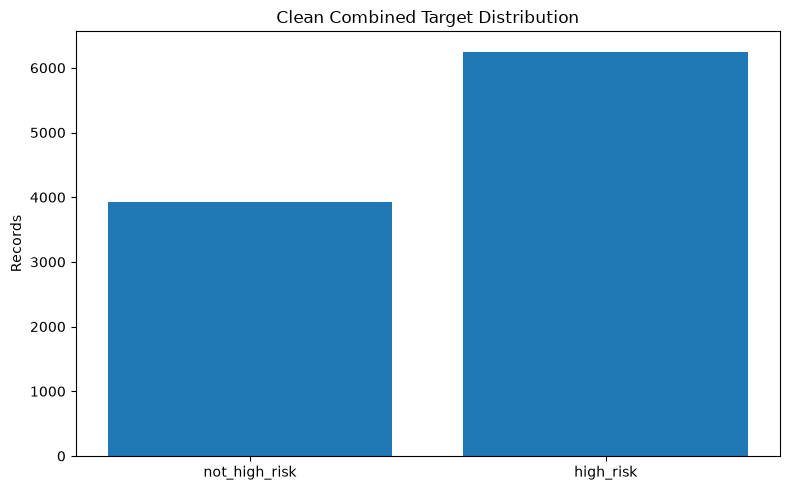

In [16]:
plt.figure(figsize=(8, 5))
target_counts = pooled_clean["target"].value_counts().sort_index()
plt.bar(
    ["not_high_risk", "high_risk"],
    target_counts.values,
)
plt.title("Clean Combined Target Distribution")
plt.ylabel("Records")
plt.tight_layout()
plt.show()

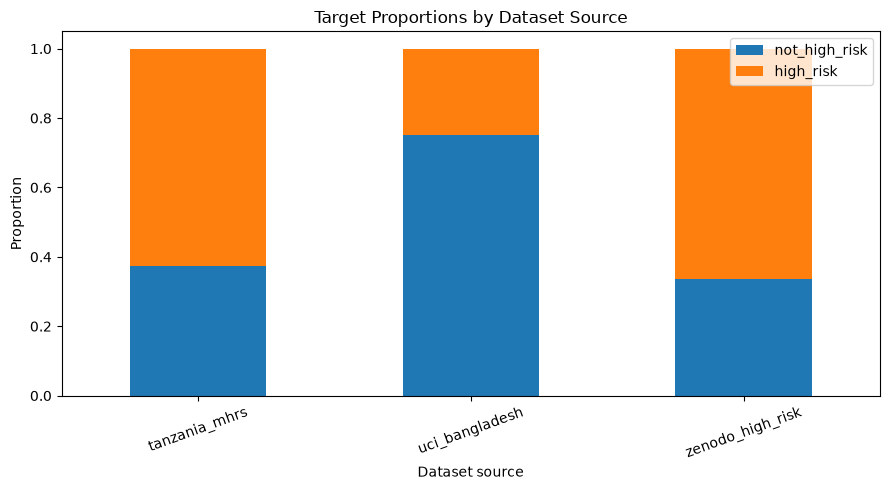

In [17]:
source_target = pd.crosstab(
    pooled_clean["dataset_source"],
    pooled_clean["target"],
    normalize="index",
)

source_target.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
)
plt.title("Target Proportions by Dataset Source")
plt.xlabel("Dataset source")
plt.ylabel("Proportion")
plt.legend(["not_high_risk", "high_risk"])
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Step 17 — Portable leakage-safe feature engineering

In [18]:
%%writefile maternalguard_features_v3.py
from __future__ import annotations

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin


class MaternalGuardFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, base_features):
        # Store constructor parameter without modification for sklearn.clone().
        self.base_features = base_features

    def fit(self, X, y=None):
        self.feature_names_in_ = np.asarray(
            list(self.base_features),
            dtype=object,
        )
        return self

    def transform(self, X):
        features = list(self.base_features)

        if isinstance(X, pd.DataFrame):
            frame = X.reindex(columns=features).copy()
        else:
            frame = pd.DataFrame(X, columns=features)

        frame = frame.apply(pd.to_numeric, errors="coerce")
        eps = 1e-8

        if {"systolic_bp", "diastolic_bp"}.issubset(frame.columns):
            frame["pulse_pressure"] = (
                frame["systolic_bp"] - frame["diastolic_bp"]
            )
            frame["mean_arterial_pressure"] = (
                frame["systolic_bp"]
                + 2.0 * frame["diastolic_bp"]
            ) / 3.0
            frame["bp_ratio"] = (
                frame["systolic_bp"]
                / (frame["diastolic_bp"].abs() + eps)
            )
            frame["bp_interaction"] = (
                frame["systolic_bp"]
                * frame["diastolic_bp"]
            )

        if {"heart_rate", "systolic_bp"}.issubset(frame.columns):
            frame["shock_index"] = (
                frame["heart_rate"]
                / (frame["systolic_bp"].abs() + eps)
            )

        if "age" in frame.columns:
            frame["age_squared"] = frame["age"] ** 2

        if "gestational_age" in frame.columns:
            frame["gestational_age_squared"] = (
                frame["gestational_age"] ** 2
            )
            frame["third_trimester_indicator"] = (
                frame["gestational_age"] >= 28
            ).astype(float)

        if "gravida" in frame.columns:
            frame["multigravida_indicator"] = (
                frame["gravida"] >= 2
            ).astype(float)

        if "blood_sugar" in frame.columns:
            frame["blood_sugar_log1p"] = np.log1p(
                frame["blood_sugar"].clip(lower=0)
            )

        if "body_temp" in frame.columns:
            frame["temperature_deviation_37c"] = (
                frame["body_temp"] - 37.0
            ).abs()

        if {"age", "bmi"}.issubset(frame.columns):
            frame["age_bmi_interaction"] = (
                frame["age"] * frame["bmi"]
            )

        frame["available_feature_count"] = frame.notna().sum(axis=1)
        return frame

Writing maternalguard_features_v3.py


In [19]:
from sklearn.base import clone
from maternalguard_features_v3 import MaternalGuardFeatureEngineer

transformer_check = MaternalGuardFeatureEngineer(
    tuple(SELECTED_BASE_FEATURES)
)
clone(transformer_check)

print("Custom transformer clone check passed.")

Custom transformer clone check passed.


## Step 18 — Source/class-balanced sample weights

Each source and class combination contributes equal total weight. Tanzania therefore cannot dominate the model merely because it has more rows.

In [20]:
def calculate_source_class_weights(
    sources: pd.Series,
    targets: pd.Series,
) -> np.ndarray:
    table = pd.DataFrame({
        "source": sources.reset_index(drop=True),
        "target": targets.reset_index(drop=True),
    })

    counts = table.groupby(
        ["source", "target"]
    ).size()

    weights = []

    for source, target in zip(
        table["source"],
        table["target"],
    ):
        weights.append(
            1.0 / float(counts.loc[(source, target)])
        )

    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.mean()
    return weights


all_weights = calculate_source_class_weights(
    pooled_clean["dataset_source"],
    pooled_clean["target"],
)

weight_audit = pd.DataFrame({
    "dataset_source": pooled_clean["dataset_source"],
    "target": pooled_clean["target"],
    "weight": all_weights,
}).groupby(
    ["dataset_source", "target"]
).agg(
    rows=("weight", "size"),
    total_weight=("weight", "sum"),
    mean_weight=("weight", "mean"),
)

display(weight_audit.round(4))

rows  total_weight  mean_weight
dataset_source   target                                 
tanzania_mhrs    0       3303        1697.0       0.5138
                 1       5508        1697.0       0.3081
uci_bangladesh   0        299        1697.0       5.6756
                 1         99        1697.0      17.1414
zenodo_high_risk 0        328        1697.0       5.1738
                 1        645        1697.0       2.6310

## Step 19 — Source-stratified, group-safe train/test split

The stratification label combines source and target, ensuring all three sources and both classes appear in the primary held-out test fold.

In [21]:
X_all = pooled_clean[SELECTED_BASE_FEATURES].copy()
y_all = pooled_clean["target"].copy()
source_all = pooled_clean["dataset_source"].copy()
groups_all = pooled_clean["record_signature"].copy()

composite_strata = (
    source_all.astype(str)
    + "__class_"
    + y_all.astype(str)
)

outer_splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

train_indices, test_indices = next(
    outer_splitter.split(
        X_all,
        composite_strata,
        groups=groups_all,
    )
)

X_train = X_all.iloc[train_indices].reset_index(drop=True)
X_test = X_all.iloc[test_indices].reset_index(drop=True)
y_train = y_all.iloc[train_indices].reset_index(drop=True)
y_test = y_all.iloc[test_indices].reset_index(drop=True)

source_train = source_all.iloc[train_indices].reset_index(drop=True)
source_test = source_all.iloc[test_indices].reset_index(drop=True)
groups_train = groups_all.iloc[train_indices].reset_index(drop=True)
groups_test = groups_all.iloc[test_indices].reset_index(drop=True)

assert set(groups_train).isdisjoint(set(groups_test))

split_audit = pd.crosstab(
    source_train,
    y_train,
).join(
    pd.crosstab(
        source_test,
        y_test,
    ),
    lsuffix="_train",
    rsuffix="_test",
)

display(split_audit)

for source_name in pooled_clean["dataset_source"].unique():
    if source_name not in set(source_train):
        raise RuntimeError(f"{source_name} missing from training set.")
    if source_name not in set(source_test):
        raise RuntimeError(f"{source_name} missing from test set.")

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

target,0_train,1_train,0_test,1_test
dataset_source,,,,
tanzania_mhrs,2642,4407,661,1101
uci_bangladesh,239,79,60,20
zenodo_high_risk,262,516,66,129


Training rows: 8145
Test rows: 2037


## Step 20 — Preprocessing and candidate models

In [22]:
linear_preprocessor = Pipeline([
    (
        "feature_engineering",
        MaternalGuardFeatureEngineer(
            tuple(SELECTED_BASE_FEATURES)
        ),
    ),
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=False,
        ),
    ),
    ("scaler", RobustScaler()),
])

tree_preprocessor = Pipeline([
    (
        "feature_engineering",
        MaternalGuardFeatureEngineer(
            tuple(SELECTED_BASE_FEATURES)
        ),
    ),
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=False,
        ),
    ),
])

CANDIDATE_MODELS = {
    "logistic_regression": Pipeline([
        ("preprocess", linear_preprocessor),
        ("model", LogisticRegression(
            class_weight=None,
            max_iter=5000,
            random_state=SEED,
        )),
    ]),
    "random_forest": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=600,
            min_samples_leaf=3,
            class_weight=None,
            random_state=SEED,
            n_jobs=1,
        )),
    ]),
    "extra_trees": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", ExtraTreesClassifier(
            n_estimators=600,
            min_samples_leaf=3,
            class_weight=None,
            random_state=SEED,
            n_jobs=1,
        )),
    ]),
    "xgboost": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            n_estimators=500,
            max_depth=4,
            learning_rate=0.04,
            min_child_weight=3,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.01,
            reg_lambda=3.0,
            random_state=SEED,
            tree_method="hist",
            n_jobs=1,
        )),
    ]),
}

print("Candidate models:", list(CANDIDATE_MODELS))

Candidate models: ['logistic_regression', 'random_forest', 'extra_trees', 'xgboost']


## Step 21 — Safety-focused metrics

In [23]:
from sklearn.metrics import make_scorer


def high_risk_recall(
    y_true,
    y_pred,
    sample_weight=None,
) -> float:
    return recall_score(
        y_true,
        y_pred,
        pos_label=1,
        sample_weight=sample_weight,
        zero_division=0,
    )


def high_risk_precision(
    y_true,
    y_pred,
    sample_weight=None,
) -> float:
    return precision_score(
        y_true,
        y_pred,
        pos_label=1,
        sample_weight=sample_weight,
        zero_division=0,
    )


def safety_score(
    y_true,
    y_pred,
    sample_weight=None,
) -> float:
    recall = high_risk_recall(
        y_true,
        y_pred,
        sample_weight,
    )
    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        sample_weight=sample_weight,
        zero_division=0,
    )
    balanced = balanced_accuracy_score(
        y_true,
        y_pred,
        sample_weight=sample_weight,
    )
    return (
        0.55 * recall
        + 0.30 * macro_f1
        + 0.15 * balanced
    )


SCORING = {
    "safety": make_scorer(safety_score),
    "roc_auc": "roc_auc",
    "balanced_accuracy": make_scorer(
        balanced_accuracy_score
    ),
    "macro_f1": make_scorer(
        f1_score,
        average="macro",
        zero_division=0,
    ),
    "high_risk_recall": make_scorer(
        high_risk_recall
    ),
    "high_risk_precision": make_scorer(
        high_risk_precision
    ),
}

## Step 22 — Group-safe cross-validation splits

In [24]:
train_composite_strata = (
    source_train.astype(str)
    + "__class_"
    + y_train.astype(str)
)

inner_splitter = StratifiedGroupKFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=SEED,
)

CV_SPLIT_INDICES = list(
    inner_splitter.split(
        X_train,
        train_composite_strata,
        groups=groups_train,
    )
)

print("CV folds:", len(CV_SPLIT_INDICES))

CV folds: 5


## Step 23 — Weighted cross-validation benchmark

Weights are recalculated inside every fold so that source/class balancing does not leak validation-fold frequencies into training.

In [25]:
def evaluate_pipeline_cv(
    estimator: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
    sources: pd.Series,
    splits: list[tuple[np.ndarray, np.ndarray]],
) -> dict:
    fold_rows = []

    for fold_number, (fit_indices, validation_indices) in enumerate(
        splits,
        start=1,
    ):
        model = clone(estimator)

        X_fit = X.iloc[fit_indices]
        y_fit = y.iloc[fit_indices]
        source_fit = sources.iloc[fit_indices]

        X_validation = X.iloc[validation_indices]
        y_validation = y.iloc[validation_indices]
        source_validation = sources.iloc[validation_indices]

        fit_weights = calculate_source_class_weights(
            source_fit,
            y_fit,
        )
        validation_weights = calculate_source_class_weights(
            source_validation,
            y_validation,
        )

        model.fit(
            X_fit,
            y_fit,
            model__sample_weight=fit_weights,
        )

        probabilities = model.predict_proba(X_validation)[:, 1]
        predictions = (probabilities >= 0.5).astype(int)

        fold_rows.append({
            "fold": fold_number,
            "safety": safety_score(
                y_validation,
                predictions,
                sample_weight=validation_weights,
            ),
            "roc_auc": roc_auc_score(
                y_validation,
                probabilities,
                sample_weight=validation_weights,
            ),
            "balanced_accuracy": balanced_accuracy_score(
                y_validation,
                predictions,
                sample_weight=validation_weights,
            ),
            "macro_f1": f1_score(
                y_validation,
                predictions,
                average="macro",
                sample_weight=validation_weights,
                zero_division=0,
            ),
            "high_risk_recall": high_risk_recall(
                y_validation,
                predictions,
                sample_weight=validation_weights,
            ),
            "high_risk_precision": high_risk_precision(
                y_validation,
                predictions,
                sample_weight=validation_weights,
            ),
        })

    return pd.DataFrame(fold_rows)


benchmark_rows = []
fold_reports = {}

for model_name, estimator in CANDIDATE_MODELS.items():
    print("Evaluating:", model_name)

    fold_report = evaluate_pipeline_cv(
        estimator=estimator,
        X=X_train,
        y=y_train,
        sources=source_train,
        splits=CV_SPLIT_INDICES,
    )
    fold_reports[model_name] = fold_report

    benchmark_rows.append({
        "model": model_name,
        "mean_safety": fold_report["safety"].mean(),
        "std_safety": fold_report["safety"].std(),
        "mean_roc_auc": fold_report["roc_auc"].mean(),
        "mean_balanced_accuracy": (
            fold_report["balanced_accuracy"].mean()
        ),
        "mean_macro_f1": fold_report["macro_f1"].mean(),
        "mean_high_risk_recall": (
            fold_report["high_risk_recall"].mean()
        ),
        "mean_high_risk_precision": (
            fold_report["high_risk_precision"].mean()
        ),
    })

benchmark = (
    pd.DataFrame(benchmark_rows)
    .sort_values("mean_safety", ascending=False)
    .reset_index(drop=True)
)

display(benchmark.round(4))

benchmark.to_csv(
    ARTIFACT_DIR / "model_benchmark.csv",
    index=False,
)

for model_name, report in fold_reports.items():
    report.to_csv(
        ARTIFACT_DIR / f"cv_folds_{model_name}.csv",
        index=False,
    )

Evaluating: logistic_regression
Evaluating: random_forest
Evaluating: extra_trees
Evaluating: xgboost


,model,mean_safety,std_safety,mean_roc_auc,mean_balanced_accuracy,mean_macro_f1,mean_high_risk_recall,mean_high_risk_precision
0,random_forest,0.8037,0.0198,0.8888,0.7972,0.7972,0.8091,0.7908
1,extra_trees,0.7941,0.0165,0.8749,0.7758,0.7755,0.8092,0.7588
2,xgboost,0.7814,0.0156,0.8876,0.7956,0.7955,0.7698,0.8120
3,logistic_regression,0.6153,0.0145,0.7340,0.6514,0.6499,0.5866,0.6749


## Step 24 — Hyperparameter tuning

In [26]:
best_family = benchmark.iloc[0]["model"]
search_estimator = clone(CANDIDATE_MODELS[best_family])

PARAMETER_SPACES = {
    "logistic_regression": {
        "model__C": loguniform(1e-3, 1e2),
    },
    "random_forest": {
        "model__n_estimators": randint(350, 1100),
        "model__max_depth": [None, 5, 8, 12, 16, 24],
        "model__min_samples_split": randint(2, 20),
        "model__min_samples_leaf": randint(1, 10),
        "model__max_features": [
            "sqrt", "log2", 0.6, 0.8, None
        ],
    },
    "extra_trees": {
        "model__n_estimators": randint(350, 1100),
        "model__max_depth": [None, 5, 8, 12, 16, 24],
        "model__min_samples_split": randint(2, 20),
        "model__min_samples_leaf": randint(1, 10),
        "model__max_features": [
            "sqrt", "log2", 0.6, 0.8, None
        ],
    },
    "xgboost": {
        "model__n_estimators": randint(250, 1000),
        "model__max_depth": randint(2, 9),
        "model__learning_rate": loguniform(0.01, 0.20),
        "model__min_child_weight": randint(1, 12),
        "model__subsample": uniform(0.65, 0.35),
        "model__colsample_bytree": uniform(0.65, 0.35),
        "model__reg_alpha": loguniform(1e-5, 2.0),
        "model__reg_lambda": loguniform(0.1, 15.0),
    },
}

training_weights = calculate_source_class_weights(
    source_train,
    y_train,
)

search = RandomizedSearchCV(
    estimator=search_estimator,
    param_distributions=PARAMETER_SPACES[best_family],
    n_iter=SEARCH_ITERATIONS,
    scoring=SCORING,
    refit="safety",
    cv=CV_SPLIT_INDICES,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    error_score="raise",
)

search.fit(
    X_train,
    y_train,
    model__sample_weight=training_weights,
)

best_estimator = search.best_estimator_

print("Best model family:", best_family)
print("Best weighted CV safety:", round(search.best_score_, 4))
print("Best parameters:")
print(json.dumps(search.best_params_, indent=2, default=str))

search_results = (
    pd.DataFrame(search.cv_results_)
    .sort_values("rank_test_safety")
)
search_results.to_csv(
    ARTIFACT_DIR / "hyperparameter_search_results.csv",
    index=False,
)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best model family: random_forest
Best weighted CV safety: 0.6862
Best parameters:
{
  "model__max_depth": 24,
  "model__max_features": "log2",
  "model__min_samples_leaf": 5,
  "model__min_samples_split": 2,
  "model__n_estimators": 809
}


## Step 25 — Weighted out-of-fold probabilities and threshold optimization

In [27]:
oof_probabilities = np.full(
    len(X_train),
    np.nan,
    dtype=float,
)

for fit_indices, validation_indices in CV_SPLIT_INDICES:
    model = clone(best_estimator)

    fold_weights = calculate_source_class_weights(
        source_train.iloc[fit_indices],
        y_train.iloc[fit_indices],
    )

    model.fit(
        X_train.iloc[fit_indices],
        y_train.iloc[fit_indices],
        model__sample_weight=fold_weights,
    )

    oof_probabilities[validation_indices] = (
        model.predict_proba(
            X_train.iloc[validation_indices]
        )[:, 1]
    )

if np.isnan(oof_probabilities).any():
    raise RuntimeError("OOF probability generation is incomplete.")

threshold_evaluation_weights = calculate_source_class_weights(
    source_train,
    y_train,
)

threshold_rows = []

for threshold in np.round(
    np.arange(0.10, 0.91, 0.01),
    2,
):
    predictions = (
        oof_probabilities >= threshold
    ).astype(int)

    threshold_rows.append({
        "threshold": float(threshold),
        "weighted_recall": high_risk_recall(
            y_train,
            predictions,
            sample_weight=threshold_evaluation_weights,
        ),
        "weighted_precision": high_risk_precision(
            y_train,
            predictions,
            sample_weight=threshold_evaluation_weights,
        ),
        "weighted_macro_f1": f1_score(
            y_train,
            predictions,
            average="macro",
            sample_weight=threshold_evaluation_weights,
            zero_division=0,
        ),
        "weighted_balanced_accuracy": balanced_accuracy_score(
            y_train,
            predictions,
            sample_weight=threshold_evaluation_weights,
        ),
        "unweighted_recall": high_risk_recall(
            y_train,
            predictions,
        ),
        "unweighted_precision": high_risk_precision(
            y_train,
            predictions,
        ),
    })

threshold_table = pd.DataFrame(threshold_rows)

eligible = threshold_table[
    threshold_table["weighted_recall"]
    >= TARGET_HIGH_RISK_RECALL
].copy()

if len(eligible):
    selected_threshold_row = eligible.sort_values(
        [
            "weighted_macro_f1",
            "weighted_precision",
            "threshold",
        ],
        ascending=[False, False, False],
    ).iloc[0]
else:
    threshold_table["fallback_score"] = (
        0.70 * threshold_table["weighted_recall"]
        + 0.30 * threshold_table["weighted_macro_f1"]
    )
    selected_threshold_row = threshold_table.sort_values(
        "fallback_score",
        ascending=False,
    ).iloc[0]

HIGH_RISK_THRESHOLD = float(
    selected_threshold_row["threshold"]
)

print("Selected high-risk threshold:", HIGH_RISK_THRESHOLD)
display(selected_threshold_row.to_frame("value"))

threshold_table.to_csv(
    ARTIFACT_DIR / "threshold_analysis.csv",
    index=False,
)

Selected high-risk threshold: 0.37


,value
threshold,0.370000
weighted_recall,0.909782
weighted_precision,0.710159
weighted_macro_f1,0.764584
weighted_balanced_accuracy,0.769234
unweighted_recall,0.923431
unweighted_precision,0.692711


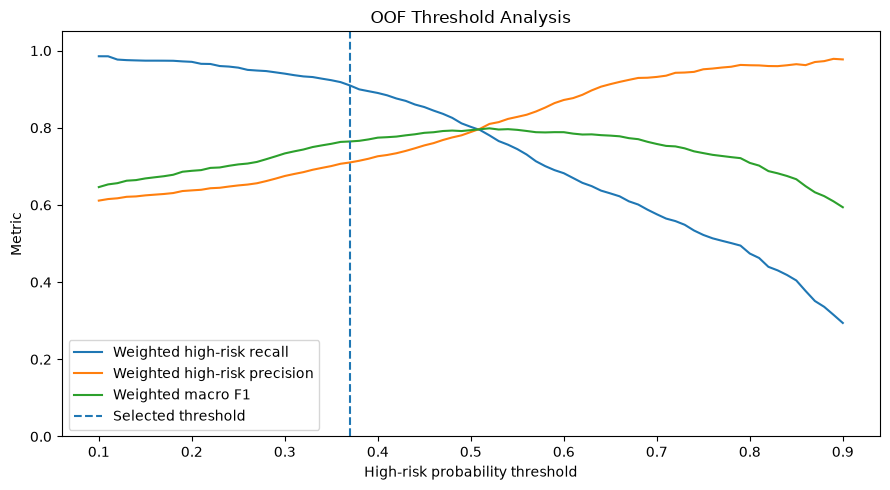

In [28]:
plt.figure(figsize=(9, 5))
plt.plot(
    threshold_table["threshold"],
    threshold_table["weighted_recall"],
    label="Weighted high-risk recall",
)
plt.plot(
    threshold_table["threshold"],
    threshold_table["weighted_precision"],
    label="Weighted high-risk precision",
)
plt.plot(
    threshold_table["threshold"],
    threshold_table["weighted_macro_f1"],
    label="Weighted macro F1",
)
plt.axvline(
    HIGH_RISK_THRESHOLD,
    linestyle="--",
    label="Selected threshold",
)
plt.title("OOF Threshold Analysis")
plt.xlabel("High-risk probability threshold")
plt.ylabel("Metric")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

## Step 26 — Fit decision and calibrated probability models

In [29]:
decision_model = clone(best_estimator)
decision_model.fit(
    X_train,
    y_train,
    model__sample_weight=training_weights,
)

# Calibration is intentionally separated from threshold selection.
probability_model = CalibratedClassifierCV(
    estimator=clone(best_estimator),
    method="sigmoid",
    cv=CV_SPLIT_INDICES,
    ensemble=True,
    n_jobs=-1,
)
probability_model.fit(X_train, y_train)

print("Decision model and probability model fitted.")

Decision model and probability model fitted.


## Step 27 — Primary held-out test evaluation

In [30]:
raw_test_probabilities = (
    decision_model.predict_proba(X_test)[:, 1]
)
calibrated_test_probabilities = (
    probability_model.predict_proba(X_test)[:, 1]
)

test_predictions = (
    raw_test_probabilities >= HIGH_RISK_THRESHOLD
).astype(int)

test_weights = calculate_source_class_weights(
    source_test,
    y_test,
)

test_metrics = {
    "rows": int(len(y_test)),
    "accuracy": accuracy_score(
        y_test,
        test_predictions,
    ),
    "balanced_accuracy": balanced_accuracy_score(
        y_test,
        test_predictions,
    ),
    "macro_f1": f1_score(
        y_test,
        test_predictions,
        average="macro",
        zero_division=0,
    ),
    "high_risk_recall": high_risk_recall(
        y_test,
        test_predictions,
    ),
    "high_risk_precision": high_risk_precision(
        y_test,
        test_predictions,
    ),
    "roc_auc": roc_auc_score(
        y_test,
        calibrated_test_probabilities,
    ),
    "log_loss": log_loss(
        y_test,
        calibrated_test_probabilities,
    ),
    "source_balanced_accuracy": balanced_accuracy_score(
        y_test,
        test_predictions,
        sample_weight=test_weights,
    ),
    "source_balanced_macro_f1": f1_score(
        y_test,
        test_predictions,
        average="macro",
        sample_weight=test_weights,
        zero_division=0,
    ),
    "source_balanced_high_risk_recall": high_risk_recall(
        y_test,
        test_predictions,
        sample_weight=test_weights,
    ),
    "source_balanced_high_risk_precision": high_risk_precision(
        y_test,
        test_predictions,
        sample_weight=test_weights,
    ),
    "source_balanced_roc_auc": roc_auc_score(
        y_test,
        calibrated_test_probabilities,
        sample_weight=test_weights,
    ),
    "threshold": HIGH_RISK_THRESHOLD,
}

print(json.dumps(test_metrics, indent=2))
print()
print(classification_report(
    y_test,
    test_predictions,
    target_names=[
        "not_high_risk",
        "high_risk",
    ],
    zero_division=0,
))

{
  "rows": 2037,
  "accuracy": 0.6877761413843888,
  "balanced_accuracy": 0.6220548919949174,
  "macro_f1": 0.6167337230492509,
  "high_risk_recall": 0.9112,
  "high_risk_precision": 0.6844951923076923,
  "roc_auc": 0.7484188055908514,
  "log_loss": 0.5606964817272989,
  "source_balanced_accuracy": 0.7648008740128209,
  "source_balanced_macro_f1": 0.7587903864255277,
  "source_balanced_high_risk_recall": 0.9226555844228997,
  "source_balanced_high_risk_precision": 0.7012609089990084,
  "source_balanced_roc_auc": 0.8496454823513341,
  "threshold": 0.37
}

               precision    recall  f1-score   support

not_high_risk       0.70      0.33      0.45       787
    high_risk       0.68      0.91      0.78      1250

     accuracy                           0.69      2037
    macro avg       0.69      0.62      0.62      2037
 weighted avg       0.69      0.69      0.65      2037



<Figure size 700x600 with 0 Axes>

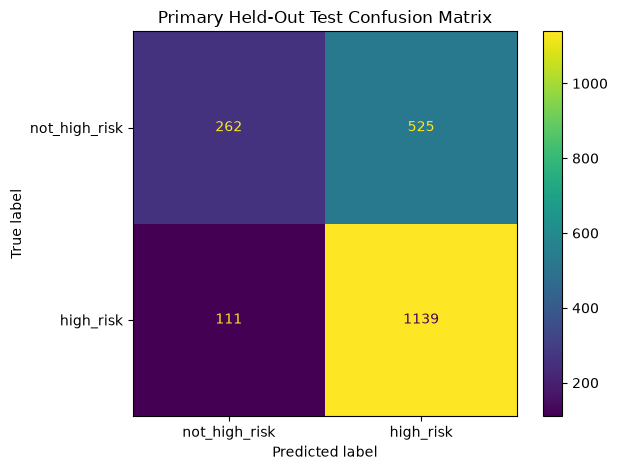

In [31]:
plt.figure(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=[
        "not_high_risk",
        "high_risk",
    ],
    values_format="d",
)
plt.title("Primary Held-Out Test Confusion Matrix")
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

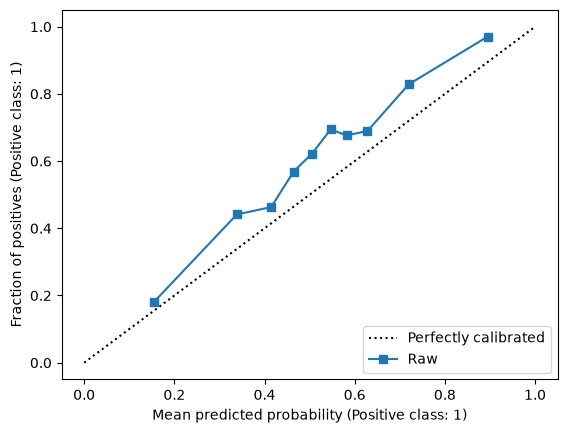

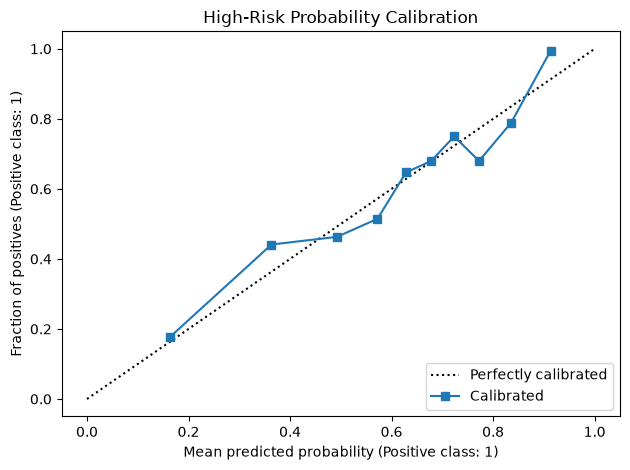

In [32]:
plt.figure(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    y_test,
    raw_test_probabilities,
    n_bins=10,
    strategy="quantile",
    name="Raw",
)
CalibrationDisplay.from_predictions(
    y_test,
    calibrated_test_probabilities,
    n_bins=10,
    strategy="quantile",
    name="Calibrated",
)
plt.title("High-Risk Probability Calibration")
plt.tight_layout()
plt.show()

## Step 28 — Per-source held-out test metrics

In [33]:
per_source_test_rows = []

for source_name in sorted(source_test.unique()):
    mask = source_test == source_name

    source_y = y_test.loc[mask]
    source_predictions = test_predictions[mask.to_numpy()]
    source_probabilities = calibrated_test_probabilities[
        mask.to_numpy()
    ]

    row = {
        "dataset_source": source_name,
        "rows": int(mask.sum()),
        "balanced_accuracy": balanced_accuracy_score(
            source_y,
            source_predictions,
        ),
        "macro_f1": f1_score(
            source_y,
            source_predictions,
            average="macro",
            zero_division=0,
        ),
        "high_risk_recall": high_risk_recall(
            source_y,
            source_predictions,
        ),
        "high_risk_precision": high_risk_precision(
            source_y,
            source_predictions,
        ),
    }

    if source_y.nunique() == 2:
        row["roc_auc"] = roc_auc_score(
            source_y,
            source_probabilities,
        )
    else:
        row["roc_auc"] = np.nan

    per_source_test_rows.append(row)

per_source_test = pd.DataFrame(per_source_test_rows)
display(per_source_test.round(4))

per_source_test.to_csv(
    ARTIFACT_DIR / "per_source_test_metrics.csv",
    index=False,
)

,dataset_source,rows,balanced_accuracy,macro_f1,high_risk_recall,high_risk_precision,roc_auc
0,tanzania_mhrs,1762,0.5788,0.5623,0.911,0.6682,0.7036
1,uci_bangladesh,80,0.8833,0.8255,0.950,0.6333,0.9392
2,zenodo_high_risk,195,0.8323,0.8372,0.907,0.8797,0.9141


## Step 29 — Leave-one-source-out domain-shift stress test

These results are not used to select the final model. They measure how strongly performance changes when an entire country/source is absent from training.

In [34]:
lodo_rows = []

for held_out_source in sorted(source_all.unique()):
    lodo_train_mask = source_all != held_out_source
    lodo_test_mask = source_all == held_out_source

    X_lodo_train = X_all.loc[lodo_train_mask].reset_index(drop=True)
    y_lodo_train = y_all.loc[lodo_train_mask].reset_index(drop=True)
    source_lodo_train = source_all.loc[lodo_train_mask].reset_index(drop=True)

    X_lodo_test = X_all.loc[lodo_test_mask].reset_index(drop=True)
    y_lodo_test = y_all.loc[lodo_test_mask].reset_index(drop=True)

    if y_lodo_train.nunique() < 2 or y_lodo_test.nunique() < 2:
        continue

    lodo_model = clone(best_estimator)
    lodo_weights = calculate_source_class_weights(
        source_lodo_train,
        y_lodo_train,
    )

    lodo_model.fit(
        X_lodo_train,
        y_lodo_train,
        model__sample_weight=lodo_weights,
    )

    probabilities = lodo_model.predict_proba(
        X_lodo_test
    )[:, 1]
    predictions = (
        probabilities >= HIGH_RISK_THRESHOLD
    ).astype(int)

    lodo_rows.append({
        "held_out_source": held_out_source,
        "rows": int(len(y_lodo_test)),
        "balanced_accuracy": balanced_accuracy_score(
            y_lodo_test,
            predictions,
        ),
        "macro_f1": f1_score(
            y_lodo_test,
            predictions,
            average="macro",
            zero_division=0,
        ),
        "high_risk_recall": high_risk_recall(
            y_lodo_test,
            predictions,
        ),
        "high_risk_precision": high_risk_precision(
            y_lodo_test,
            predictions,
        ),
        "roc_auc": roc_auc_score(
            y_lodo_test,
            probabilities,
        ),
    })

lodo_results = pd.DataFrame(lodo_rows)
display(lodo_results.round(4))

lodo_results.to_csv(
    ARTIFACT_DIR / "leave_one_source_out_stress_test.csv",
    index=False,
)

,held_out_source,rows,balanced_accuracy,macro_f1,high_risk_recall,high_risk_precision,roc_auc
0,tanzania_mhrs,8811,0.4823,0.4821,0.5851,0.6112,0.4614
1,uci_bangladesh,398,0.5117,0.2249,1.0000,0.2532,0.5938
2,zenodo_high_risk,973,0.4800,0.4336,0.3380,0.6374,0.4902


## Step 30 — Permutation feature importance

In [35]:
importance = permutation_importance(
    estimator=decision_model,
    X=X_test,
    y=y_test,
    scoring="roc_auc",
    n_repeats=20 if FAST_MODE else 50,
    random_state=SEED,
    n_jobs=-1,
)

importance_df = (
    pd.DataFrame({
        "feature": SELECTED_BASE_FEATURES,
        "importance_mean": importance.importances_mean,
        "importance_std": importance.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(importance_df.round(4))

importance_df.to_csv(
    ARTIFACT_DIR / "permutation_importance.csv",
    index=False,
)

,feature,importance_mean,importance_std
0,diastolic_bp,0.0840,0.0082
1,gravida,0.0359,0.0065
2,systolic_bp,0.0335,0.0047
3,weight_kg,0.0244,0.0038
4,heart_rate,0.0198,0.0054
5,body_temp,0.0157,0.0031
6,blood_sugar,0.0152,0.0021
7,bmi,0.0090,0.0026
8,gestational_age,0.0061,0.0021
9,height_cm,0.0018,0.0013


## Step 31 — False-negative and error analysis

In [36]:
error_analysis = X_test.copy()
error_analysis["dataset_source"] = source_test
error_analysis["true_class"] = y_test.map({
    0: "not_high_risk",
    1: "high_risk",
})
error_analysis["predicted_class"] = pd.Series(
    test_predictions
).map({
    0: "not_high_risk",
    1: "high_risk",
})
error_analysis["raw_high_risk_probability"] = (
    raw_test_probabilities
)
error_analysis["calibrated_high_risk_probability"] = (
    calibrated_test_probabilities
)
error_analysis["critical_false_negative"] = (
    (y_test.to_numpy() == 1)
    & (test_predictions == 0)
)
error_analysis["false_positive"] = (
    (y_test.to_numpy() == 0)
    & (test_predictions == 1)
)

error_analysis = error_analysis.sort_values(
    [
        "critical_false_negative",
        "false_positive",
        "raw_high_risk_probability",
    ],
    ascending=[False, False, True],
)

print(
    "Critical high-risk false negatives:",
    int(error_analysis["critical_false_negative"].sum()),
)
print(
    "False positives:",
    int(error_analysis["false_positive"].sum()),
)

display(error_analysis.head(40))

error_analysis.to_csv(
    ARTIFACT_DIR / "error_analysis.csv",
    index=False,
)

Critical high-risk false negatives: 111
False positives: 525


,age,systolic_bp,diastolic_bp,blood_sugar,body_temp,heart_rate,weight_kg,height_cm,bmi,gravida,gestational_age,dataset_source,true_class,predicted_class,raw_high_risk_probability,calibrated_high_risk_probability,critical_false_negative,false_positive
49,60.0,120.0,80.0,7.8,36.666667,75.0,NaN,NaN,NaN,NaN,NaN,uci_bangladesh,high_risk,not_high_risk,0.031550,0.075079,True,False
2032,23.0,110.0,55.0,NaN,NaN,NaN,61.0,NaN,NaN,2.0,30.0,zenodo_high_risk,high_risk,not_high_risk,0.045637,0.102135,True,False
2036,25.0,110.0,55.0,NaN,NaN,NaN,50.0,NaN,59.799502,1.0,35.0,zenodo_high_risk,high_risk,not_high_risk,0.173817,0.149023,True,False
1916,21.0,100.0,70.0,NaN,NaN,NaN,52.0,121.92,34.982709,1.0,30.0,zenodo_high_risk,high_risk,not_high_risk,0.191997,0.263626,True,False
1254,23.0,112.0,67.0,NaN,37.000000,61.0,58.0,160.00,22.656250,3.0,30.0,tanzania_mhrs,high_risk,not_high_risk,0.195532,0.197657,True,False
715,33.0,112.0,67.0,NaN,36.500000,63.0,59.0,141.00,29.676576,3.0,18.0,tanzania_mhrs,high_risk,not_high_risk,0.199507,0.145015,True,False
1783,17.0,110.0,70.0,NaN,NaN,NaN,54.0,158.00,21.631149,1.0,32.0,tanzania_mhrs,high_risk,not_high_risk,0.201496,0.131796,True,False
1438,23.0,120.0,70.0,NaN,NaN,NaN,50.0,160.00,19.531250,1.0,10.0,tanzania_mhrs,high_risk,not_high_risk,0.202758,0.146040,True,False
1244,21.0,110.0,70.0,5.6,NaN,NaN,62.0,158.00,24.835763,2.0,7.0,tanzania_mhrs,high_risk,not_high_risk,0.219484,0.259465,True,False
459,22.0,112.0,67.0,NaN,36.500000,76.0,60.0,168.00,21.258503,NaN,32.0,tanzania_mhrs,high_risk,not_high_risk,0.221135,0.177444,True,False


## Step 32 — Refit final deployment models using all clean records

In [37]:
final_training_weights = calculate_source_class_weights(
    source_all,
    y_all,
)

final_decision_model = clone(best_estimator)
final_decision_model.fit(
    X_all,
    y_all,
    model__sample_weight=final_training_weights,
)

full_composite_strata = (
    source_all.astype(str)
    + "__class_"
    + y_all.astype(str)
)

full_splitter = StratifiedGroupKFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=SEED,
)

full_cv_indices = list(
    full_splitter.split(
        X_all,
        full_composite_strata,
        groups=groups_all,
    )
)

final_probability_model = CalibratedClassifierCV(
    estimator=clone(best_estimator),
    method="sigmoid",
    cv=full_cv_indices,
    ensemble=True,
    n_jobs=-1,
)
final_probability_model.fit(X_all, y_all)

print("Final deployment models refitted on all clean records.")

Final deployment models refitted on all clean records.


## Step 33 — Save bundle, model card and reports

In [38]:
trained_at = datetime.now(timezone.utc).isoformat()

bundle = {
    "model_name": "MaternalGuard",
    "model_version": MODEL_VERSION,
    "trained_at_utc": trained_at,
    "decision_model": final_decision_model,
    "probability_model": final_probability_model,
    "selected_base_features": SELECTED_BASE_FEATURES,
    "target_definition": {
        0: "not_high_risk",
        1: "high_risk",
    },
    "high_risk_threshold": HIGH_RISK_THRESHOLD,
    "selected_model_family": best_family,
    "selected_parameters": search.best_params_,
    "training_sources": sorted(source_all.unique().tolist()),
    "training_rows": int(len(X_all)),
    "sanity_limits": SANITY_LIMITS,
}

joblib.dump(
    bundle,
    ARTIFACT_DIR / "maternalguard_bundle.joblib",
    compress=3,
)

test_predictions_export = X_test.copy()
test_predictions_export["dataset_source"] = source_test
test_predictions_export["true_target"] = y_test
test_predictions_export["predicted_target"] = test_predictions
test_predictions_export["raw_high_risk_probability"] = (
    raw_test_probabilities
)
test_predictions_export["calibrated_high_risk_probability"] = (
    calibrated_test_probabilities
)

test_predictions_export.to_csv(
    ARTIFACT_DIR / "heldout_test_predictions.csv",
    index=False,
)

model_card = {
    "model_name": "MaternalGuard",
    "version": MODEL_VERSION,
    "created_at_utc": trained_at,
    "intended_use": (
        "Research and hackathon maternal high-risk screening "
        "decision support with mandatory clinician review."
    ),
    "not_intended_for": [
        "Autonomous medical diagnosis",
        "Treatment or medication decisions",
        "Replacing qualified clinicians",
        "Deployment without Pakistani prospective validation",
    ],
    "datasets": DATASET_REGISTRY,
    "target_definition": {
        "not_high_risk": "UCI low/mid risk; source low/no",
        "high_risk": "UCI high risk; source high/yes",
    },
    "training_rows": int(len(X_all)),
    "source_rows": source_all.value_counts().to_dict(),
    "selected_features": SELECTED_BASE_FEATURES,
    "data_quality": data_quality_report,
    "split_method": (
        "Source-and-target stratified group-safe holdout. "
        "Identical signatures cannot cross folds."
    ),
    "source_class_weighting": (
        "Every dataset-source and target-class combination "
        "contributes equal total training weight."
    ),
    "selected_model_family": best_family,
    "selected_parameters": search.best_params_,
    "high_risk_threshold": HIGH_RISK_THRESHOLD,
    "heldout_test_metrics": test_metrics,
    "per_source_test_metrics": (
        per_source_test.to_dict(orient="records")
    ),
    "leave_one_source_out_stress_test": (
        lodo_results.to_dict(orient="records")
    ),
    "limitations": [
        "The three datasets use different risk definitions.",
        "The target is harmonized to binary high versus not-high risk.",
        "Some variables are unavailable in some sources.",
        "The sources were not collected in Pakistan.",
        "Cross-source performance may be substantially lower.",
        "Prospective local clinical validation is mandatory.",
    ],
}

with open(
    ARTIFACT_DIR / "model_card.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        model_card,
        file,
        indent=2,
        default=str,
    )

shutil.copy(
    "maternalguard_features_v3.py",
    ARTIFACT_DIR / "maternalguard_features_v3.py",
)

print("Saved artifact files:")
for file_path in sorted(ARTIFACT_DIR.iterdir()):
    print("-", file_path.name)

Saved artifact files:
- ambiguous_signature_rows.csv
- cv_folds_extra_trees.csv
- cv_folds_logistic_regression.csv
- cv_folds_random_forest.csv
- cv_folds_xgboost.csv
- data_quality_report.json
- error_analysis.csv
- feature_coverage_by_source.csv
- feature_selection_report.csv
- heldout_test_predictions.csv
- hyperparameter_search_results.csv
- leave_one_source_out_stress_test.csv
- maternalguard_bundle.joblib
- maternalguard_features_v3.py
- model_benchmark.csv
- model_card.json
- outlier_report.csv
- per_source_test_metrics.csv
- permutation_importance.csv
- threshold_analysis.csv


## Step 34 — Reusable inference module

In [39]:
%%writefile /content/maternalguard_v3/artifacts/inference.py
from __future__ import annotations

from pathlib import Path
from typing import Any, Mapping

import joblib
import pandas as pd

BUNDLE = joblib.load(
    Path(__file__).with_name(
        "maternalguard_bundle.joblib"
    )
)

EMERGENCY_FLAGS = {
    "heavy_bleeding",
    "convulsions",
    "loss_of_consciousness",
    "severe_breathing_difficulty",
}


def predict_maternal_risk(
    measurements: Mapping[str, float | int | None],
    symptom_flags: Mapping[str, bool] | None = None,
) -> dict[str, Any]:
    features = BUNDLE["selected_base_features"]

    frame = pd.DataFrame([{
        feature: measurements.get(feature)
        for feature in features
    }])

    if frame.notna().sum(axis=1).iloc[0] < 2:
        return {
            "status": "insufficient_input",
            "required_model_features": features,
            "message": (
                "Provide age and at least one additional "
                "clinical or pregnancy measurement."
            ),
        }

    raw_probability = float(
        BUNDLE["decision_model"]
        .predict_proba(frame)[0, 1]
    )
    calibrated_probability = float(
        BUNDLE["probability_model"]
        .predict_proba(frame)[0, 1]
    )

    high_risk = (
        raw_probability
        >= BUNDLE["high_risk_threshold"]
    )

    active_emergency_flags = sorted(
        flag
        for flag in EMERGENCY_FLAGS
        if bool((symptom_flags or {}).get(flag, False))
    )

    decision = (
        "high_risk"
        if high_risk
        else "not_high_risk"
    )
    decision_source = "ml_threshold"

    if active_emergency_flags:
        decision = "emergency_referral"
        decision_source = "clinical_rule_override"

    return {
        "status": "ok",
        "model": BUNDLE["model_name"],
        "version": BUNDLE["model_version"],
        "decision": decision,
        "decision_source": decision_source,
        "high_risk_probability": calibrated_probability,
        "raw_decision_probability": raw_probability,
        "threshold": float(
            BUNDLE["high_risk_threshold"]
        ),
        "active_emergency_flags": active_emergency_flags,
        "notice": (
            "Research decision-support only. "
            "Qualified clinical review is required."
        ),
    }

Writing /content/maternalguard_v3/artifacts/inference.py


## Step 35 — Test exported inference

In [40]:
import sys

sys.path.insert(
    0,
    str(ARTIFACT_DIR.resolve()),
)

from inference import predict_maternal_risk

sample_measurements = {
    feature: (
        float(pooled_clean[feature].median())
        if pooled_clean[feature].notna().any()
        else None
    )
    for feature in SELECTED_BASE_FEATURES
}

sample_result = predict_maternal_risk(
    measurements=sample_measurements,
    symptom_flags={
        "heavy_bleeding": False,
        "convulsions": False,
        "loss_of_consciousness": False,
        "severe_breathing_difficulty": False,
    },
)

print(json.dumps(sample_result, indent=2))

{
  "status": "ok",
  "model": "MaternalGuard",
  "version": "3.1.0",
  "decision": "high_risk",
  "decision_source": "ml_threshold",
  "high_risk_probability": 0.4988998471040246,
  "raw_decision_probability": 0.45165064606762034,
  "threshold": 0.37,
  "active_emergency_flags": [],
  "notice": "Research decision-support only. Qualified clinical review is required."
}


## Step 36 — FastAPI service for LangGraph integration

In [41]:
%%writefile /content/maternalguard_v3/artifacts/app.py
from __future__ import annotations

from typing import Any

from fastapi import FastAPI
from pydantic import BaseModel, ConfigDict, Field

from inference import predict_maternal_risk

app = FastAPI(
    title="MaaHifazat MaternalGuard API",
    version="3.1.0",
)


class ScreeningRequest(BaseModel):
    model_config = ConfigDict(extra="forbid")

    measurements: dict[str, float | int | None]
    symptom_flags: dict[str, bool] = Field(
        default_factory=dict
    )


@app.get("/health")
def health() -> dict[str, str]:
    return {
        "status": "healthy",
        "model": "MaternalGuard",
    }


@app.post("/predict")
def predict(request: ScreeningRequest) -> dict[str, Any]:
    return predict_maternal_risk(
        measurements=request.measurements,
        symptom_flags=request.symptom_flags,
    )

Writing /content/maternalguard_v3/artifacts/app.py


## Step 37 — Package and download artifacts

In [42]:
requirements_text = f"""pandas=={pd.__version__}
numpy=={np.__version__}
scikit-learn=={sklearn.__version__}
xgboost=={xgboost.__version__}
joblib=={joblib.__version__}
fastapi
uvicorn
pydantic
"""

(
    ARTIFACT_DIR / "requirements.txt"
).write_text(
    requirements_text,
    encoding="utf-8",
)

readme_text = """# MaaHifazat MaternalGuard V3

## Training sources

- UCI Maternal Health Risk
- Tanzania MHRS
- Zenodo Maternal Health and High-Risk Pregnancy

## Run API

```bash
pip install -r requirements.txt
uvicorn app:app --host 0.0.0.0 --port 8000
```

## Warning

Research and hackathon prototype only. Not an autonomous medical device.
"""

(
    ARTIFACT_DIR / "README.md"
).write_text(
    readme_text,
    encoding="utf-8",
)

archive_path = shutil.make_archive(
    "/content/MaternalGuard_V3_Artifacts",
    "zip",
    root_dir=ARTIFACT_DIR,
)

print("Created:", archive_path)

try:
    from google.colab import files
    files.download(archive_path)
except ImportError:
    print("Artifacts directory:", ARTIFACT_DIR)

Created: /content/MaternalGuard_V3_Artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Model acceptance checklist

Do not accept the trained model only because the notebook completed.

The following should all be checked:

- Total harmonized rows are at least 9,000.
- Tanzania contributes at least 7,000 rows.
- Zenodo contributes at least 900 rows.
- At least six compatible model features are selected.
- Primary test split contains every source and both classes.
- Source-balanced high-risk recall is reported.
- High-risk precision is not extremely low.
- Per-source metrics are reviewed.
- Leave-one-source-out degradation is disclosed.
- Critical false negatives are inspected.
- The model card and data-quality reports are saved.
- Pakistani prospective validation remains mandatory.